# Problem 5.16

In [1]:
import matplotlib.pyplot as plt
import numpy as np

## Part a.

In [2]:
def run_orbit(mu, n_steps=10_000_000, warm_up=10_000, x_init=0.1):
    x = x_init
    orbit = []
    for i in range(n_steps + warm_up):
        x = 4 * mu * x * (1 - x)
        if i > warm_up:
            orbit.append(x)
    
    return np.array(orbit)

In [3]:
def calc_histograms(mu, epsilons, density=True):
    orbit = run_orbit(mu)
    histograms = []
    for epsilon in epsilons:
        bins = np.arange(0, 1, epsilon)
        histograms.append(np.histogram(orbit, bins, density=density))
    return histograms

In [4]:
epsilons = np.logspace(-3, -1, num=10)

In [5]:
histograms = calc_histograms(1, epsilons)

In [6]:
def plot_histogram(histogram):
    histogram, bins = histogram
    bins = bins[:-1] + np.diff(bins) / 2
    plt.plot(bins, histogram)
    plt.xlabel('$x$')
    plt.ylabel('Probability density')
    plt.show()

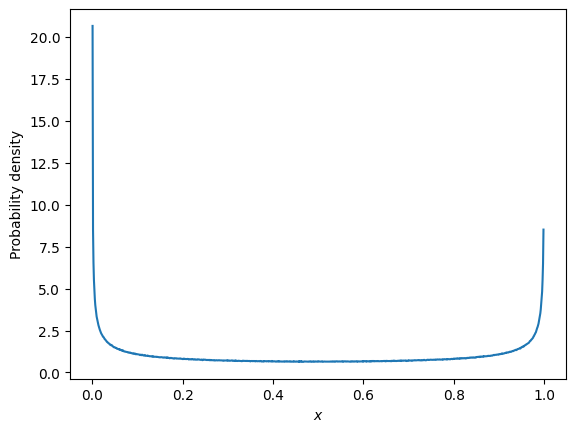

In [7]:
plot_histogram(histograms[0])

In [8]:
histograms = calc_histograms(0.8, epsilons)

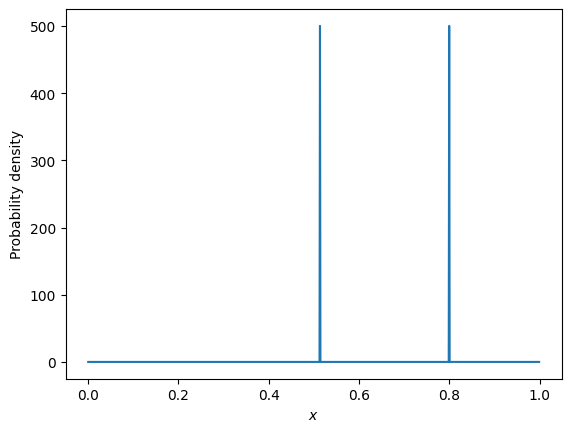

In [9]:
plot_histogram(histograms[0])

## Part b.

In [10]:
def calc_capacity_dims(mu, epsilons):
    histograms = calc_histograms(mu, epsilons, density=False)
    N_covers = []
    for histogram, _ in histograms:
        N_covers.append(np.sum(histogram > 0))
    return -np.diff(np.log(N_covers)) / np.diff(np.log(epsilons))

In [11]:
epsilons = np.logspace(-6, -1, num=50)[::-1]

In [12]:
MU_INF = 0.892486418

In [13]:
capacity_dims_0p9 = calc_capacity_dims(0.9, epsilons)
capacity_dims_0p8 = calc_capacity_dims(0.8, epsilons)
capacity_dims_inf = calc_capacity_dims(MU_INF, epsilons)

In [14]:
EXPECTED_INF_DIM = 0.538

In [15]:
epsilon_midpoints = (np.log(epsilons[:-1]) + np.log(epsilons[1:]))/2

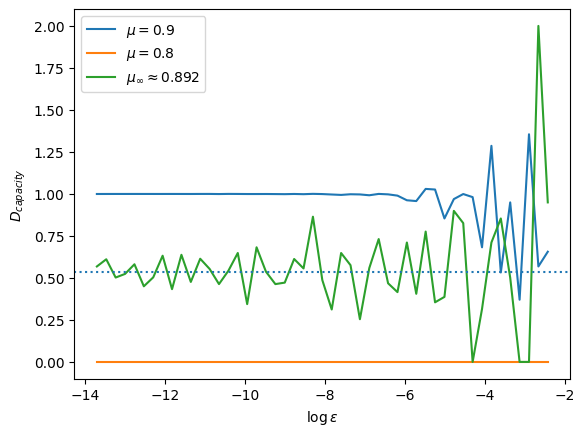

In [16]:
plt.plot(epsilon_midpoints, capacity_dims_0p9, label='$\mu = 0.9$')
plt.plot(epsilon_midpoints, capacity_dims_0p8, label='$\mu = 0.8$')
plt.plot(epsilon_midpoints, capacity_dims_inf, label=r'$\mu_{\infty} \approx 0.892$')
plt.xlabel('$\log \epsilon$')
plt.ylabel('$D_{capacity}$')
plt.axhline(EXPECTED_INF_DIM, linestyle=':')
plt.legend();

In [17]:
capacity_dims_inf_minus_eps = calc_capacity_dims(0.892486418-1e-6, epsilons)
capacity_dims_inf_plus_eps = calc_capacity_dims(0.892486418+1e-6, epsilons)

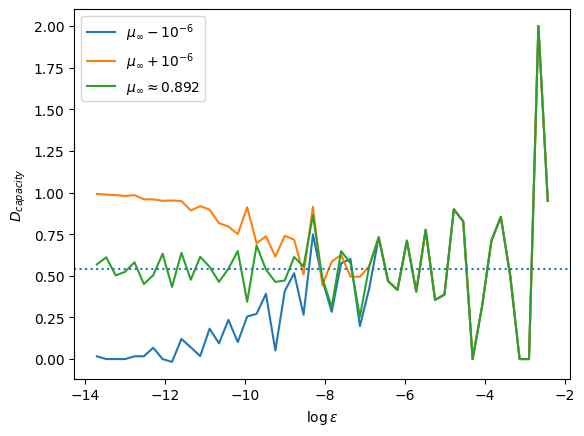

In [18]:
plt.plot(epsilon_midpoints, capacity_dims_inf_minus_eps, label='$\mu_{\infty} - 10^{-6}$')
plt.plot(epsilon_midpoints, capacity_dims_inf_plus_eps, label='$\mu_{\infty} + 10^{-6}$')
plt.plot(epsilon_midpoints, capacity_dims_inf, label=r'$\mu_{\infty} \approx 0.892$')
plt.xlabel('$\log \epsilon$')
plt.ylabel('$D_{capacity}$')
plt.axhline(EXPECTED_INF_DIM, linestyle=':')
plt.legend();

## Part c.

In [19]:
def calc_information_dims(mu, epsilons):
    histograms = calc_histograms(mu, epsilons, density=False)
    entropies = []
    for histogram, _ in histograms:
        total = np.sum(histogram)
        entropies.append(np.sum(histogram / total * np.log(histogram / total + 1e-12)))
    return np.diff(entropies) / np.diff(np.log(epsilons))

In [20]:
info_dims_0p8 = calc_information_dims(0.8, epsilons)
info_dims_0p9 = calc_information_dims(0.9, epsilons)
info_dims_inf = calc_information_dims(MU_INF, epsilons)

In [21]:
EXPECTED_INFO_DIM = 0.517098

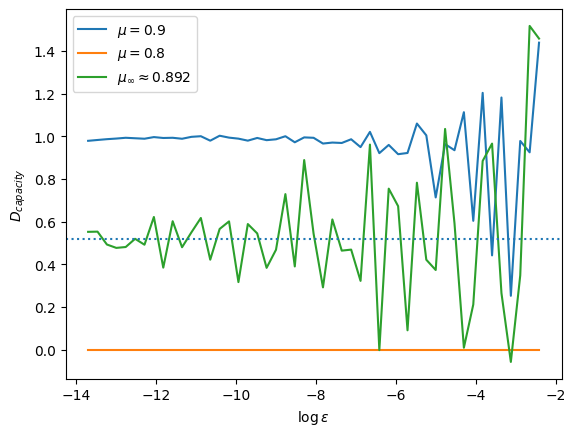

In [22]:
plt.plot(epsilon_midpoints, info_dims_0p9, label='$\mu = 0.9$')
plt.plot(epsilon_midpoints, info_dims_0p8, label='$\mu = 0.8$')
plt.plot(epsilon_midpoints, info_dims_inf, label=r'$\mu_{\infty} \approx 0.892$')
plt.xlabel('$\log \epsilon$')
plt.ylabel('$D_{capacity}$')
plt.axhline(EXPECTED_INFO_DIM, linestyle=':')
plt.legend();